epoch0,loss0.873238,acc0.5000
epoch200,loss0.002386,acc1.0000
epoch400,loss0.000892,acc1.0000
epoch600,loss0.000521,acc1.0000
epoch800,loss0.000359,acc1.0000
epoch1000,loss0.000270,acc1.0000
epoch1200,loss0.000215,acc1.0000
epoch1400,loss0.000177,acc1.0000
epoch1600,loss0.000150,acc1.0000
epoch1800,loss0.000130,acc1.0000


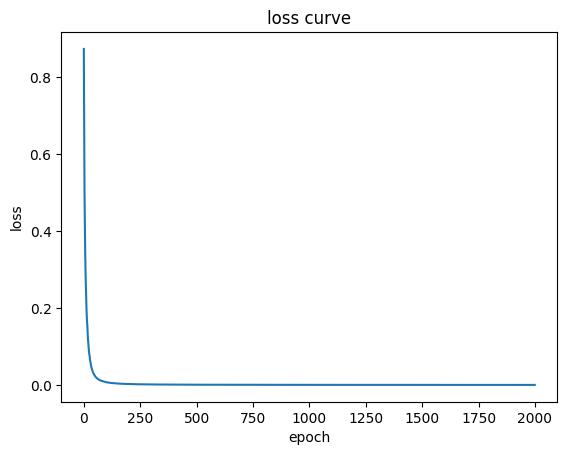

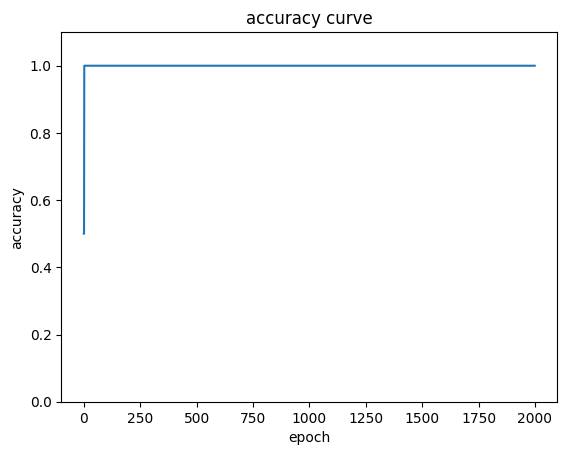

預測 [0 1 2 1]
真實 [0 1 2 1]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
X=np.array([
    [1,2],
    [2,1],
    [3,4],
    [4,3]       
])
y_label=np.array([0,1,2,1])
Y=np.zeros((4,3))
Y[np.arange(4),y_label]=1
layers=[2,16,16,8,3]
lr=0.1
epochs=2000
def relu(z):
    return np.maximum(0,z)
def back_relu(dA,Z):
    dZ=dA.copy()
    dZ[Z<=0]=0
    return dZ
def softmax(z):
    exp_z=np.exp(z-np.max(z,axis=1,keepdims=True))
    return exp_z/np.sum(exp_z,axis=1,keepdims=True)
def loss_fn(Y,y_pred,eps=1e-8):
    return -np.mean(np.sum(Y*np.log(y_pred+eps),axis=1))
def creat_model(layers):
    np.random.seed(42)
    params=[]
    for i in range(len(layers)-1):
        fan_in=layers[i]
        fan_out=layers[i+1]
        w=np.random.randn(fan_in,fan_out)*np.sqrt(2/fan_in)
        b=np.zeros((1,fan_out))
        params.append({"w":w,"b":b})
    model={
        "layers":layers,
        "params":params,
        "caches":None   
    }
    return model
def forward(model,X):#A_prev,Z
    params=model["params"]
    caches=[]
    A=X
    for i,layer in enumerate(params):
        w=layer["w"]
        b=layer["b"]
        A_prev=A
        Z=A_prev@w+b
        if i < len(params)-1:
            A=relu(Z)
        else:
            A=softmax(Z)
        caches.append({"A_prev":A_prev,"Z":Z})
    model["caches"]=caches
    return A
def backward(model,Y,y_pred):
    params=model["params"]
    caches=model["caches"]
    L=len(params)
    n=Y.shape[0]
    dA=None
    grads=[None]*L
    for i in reversed(range(L)): #range(L) L-1開始算i=0,1,2,3,L=4
        w=params[i]["w"]
        cach=caches[i]
        A_prev=cach["A_prev"]
        Z=cach["Z"]
        if i == L-1:
            dZ=y_pred-Y
        else:
            dZ=back_relu(dA,Z)
        dw=A_prev.T@dZ/n
        db=np.mean(dZ,axis=0,keepdims=True)
        dA=dZ@w.T
        grads[i]={"dw":dw,"db":db}
    return grads
def update(model,grads,lr):
    params=model["params"]
    for i in range(len(params)):
        params[i]["w"]-=lr*grads[i]["dw"]
        params[i]["b"]-=lr*grads[i]["db"]
def train(model,X,Y,epochs,lr):
    losses=[]
    accs=[]
    for epoch in range(epochs):
        y_pred=forward(model,X)      
        loss=loss_fn(Y,y_pred)
        losses.append(loss)
        grads=backward(model,Y,y_pred)
        update(model,grads,lr)
        y_pred_label=np.argmax(y_pred,axis=1)
        acc=np.mean(y_pred_label==y_label)################(y_pred_label==y_label)
        accs.append(acc)
        if epoch % 200 == 0:
            print(f"epoch{epoch},loss{loss:.6f},acc{acc:.4f}")
    return losses,accs
def predict(model,X):
    y_pred=forward(model,X)
    return np.argmax(y_pred,axis=1)
model=creat_model([2,8,16,16,3])
losses,accs=train(model,X,Y,epochs=epochs,lr=lr)
plt.plot(losses)
plt.title("loss curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()
plt.plot(accs)
plt.title("accuracy curve")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.ylim(0,1.1)
plt.show()
pred=predict(model,X)
print("預測",pred)
print("真實",y_label)